# Fake News Detection with DistilBERT

Fine-tune **distilbert-base-uncased** on the ISOT Fake News dataset for binary classification.

| Step | Description |
|------|-------------|
| 1 | Load & inspect cleaned dataset |
| 2 | Train / Validation / Test split (70/15/15) |
| 3 | Tokenize with DistilBERT tokenizer |
| 4 | Build PyTorch Dataset |
| 5 | Fine-tune with Hugging Face Trainer |
| 6 | Evaluate on test set |
| 7 | Plot loss curves |
| 8 | Save model & tokenizer |
| 9 | Inference function `predict_text()` |

## 0. Imports & Device Setup

In [2]:
import os

# Prevent transformers from trying to reach Hugging Face Hub on import
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Device  : {DEVICE}")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5090
Device  : cuda


## 1. Load & Inspect the Dataset

In [3]:
DATA_PATH = "data/fake_news_full_clean.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df[['content','label']].isnull().sum().to_string()}")
print(f"\nClass distribution:")
print(df["label"].value_counts().rename({0: "Real (0)", 1: "Fake (1)"}))

Shape : (39103, 6)
Columns: ['title', 'text', 'content', 'subject', 'date', 'label']

Missing values:
content    0
label      0

Class distribution:
label
Real (0)    21196
Fake (1)    17907
Name: count, dtype: int64


In [4]:
print("--- Sample rows ---")
df[["content", "label"]].sample(5, random_state=42)

--- Sample rows ---


,content,label
3510,First Somali Refugee Elected In American Histo...,1
11306,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...,1
5035,GOP Third-Party Candidate Live-Tweets Trump’s ...,1
9240,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...,1
35734,Iran warns U.S. against imposing further sanct...,0


## 2. Train / Validation / Test Split

- 70% train / 15% validation / 15% test
- Stratified to preserve class balance in every split

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = dict(split["label"].value_counts())
    print(f"{name:>5}: {len(split):>6} rows  |  Real={dist.get(0,0):>5}  Fake={dist.get(1,0):>5}")

Train:  27372 rows  |  Real=14837  Fake=12535
  Val:   5865 rows  |  Real= 3179  Fake= 2686
 Test:   5866 rows  |  Real= 3180  Fake= 2686


## 3. Tokenization

| Parameter | Value | Why |
|-----------|-------|-----|
| `max_length` | 256 | Covers most article openings; longer texts are truncated |
| `truncation` | True | Prevents errors on very long articles |
| `padding` | `max_length` | Ensures all tensors have the same shape |

In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

sample_enc = tokenizer(
    "This is a test sentence for tokenization.",
    max_length=MAX_LENGTH,
    truncation=True,
    padding="max_length",
)
print(f"Tokenizer  : {MODEL_NAME}")
print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Sample len : {len(sample_enc['input_ids'])} (should be {MAX_LENGTH})")

Tokenizer  : distilbert-base-uncased
Vocab size : 30,522
Sample len : 256 (should be 256)


## 4. PyTorch Dataset

A thin wrapper that tokenizes on-the-fly in `__getitem__` so we don't
need to hold all tokenized data in memory at once.

In [7]:
class NewsDataset(Dataset):
    """Wraps a DataFrame for the Hugging Face Trainer."""

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe["content"].tolist()
        self.labels     = dataframe["label"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = NewsDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = NewsDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = NewsDataset(test_df,  tokenizer, MAX_LENGTH)

print(f"Datasets created — Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

item = train_dataset[0]
print(f"Sample keys   : {list(item.keys())}")
print(f"input_ids     : {item['input_ids'].shape}")
print(f"attention_mask: {item['attention_mask'].shape}")
print(f"label         : {item['labels'].item()}")

Datasets created — Train: 27372  Val: 5865  Test: 5866
Sample keys   : ['input_ids', 'attention_mask', 'labels']
input_ids     : torch.Size([256])
attention_mask: torch.Size([256])
label         : 0


## 5. Fine-Tune DistilBERT

The Hugging Face `Trainer` handles:
- Training loop with gradient accumulation
- Mixed-precision (fp16) for faster GPU training
- Evaluation at the end of every epoch
- Automatic checkpoint saving & best-model selection

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:>12,}")
print(f"Trainable parameters : {train_:>12,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     :   66,955,010
Trainable parameters :   66,955,010


In [9]:
def compute_metrics(eval_pred):
    """Called by Trainer at end of each eval phase."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [10]:
SAVE_DIR = "models/fake_news_model"

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Starting training...


In [11]:
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"  Total steps   : {train_result.global_step}")
print(f"  Training loss : {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.004456,0.004293,0.998977,0.998512,0.999255,0.998884
2,0.000922,0.000160,1.000000,1.000000,1.000000,1.000000
3,0.000098,0.000088,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete.
  Total steps   : 2568
  Training loss : 0.0234


## 6. Evaluation on Test Set

In [12]:
test_output = trainer.predict(test_dataset)
test_preds  = np.argmax(test_output.predictions, axis=-1)
test_labels = test_df["label"].values

m = test_output.metrics
print("=" * 50)
print("         TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {m['test_accuracy']:.4f}")
print(f"  Precision : {m['test_precision']:.4f}")
print(f"  Recall    : {m['test_recall']:.4f}")
print(f"  F1 Score  : {m['test_f1']:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=["Real", "Fake"]))

         TEST SET RESULTS
  Accuracy  : 0.9997
  Precision : 0.9993
  Recall    : 1.0000
  F1 Score  : 0.9996

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      3180
        Fake       1.00      1.00      1.00      2686

    accuracy                           1.00      5866
   macro avg       1.00      1.00      1.00      5866
weighted avg       1.00      1.00      1.00      5866



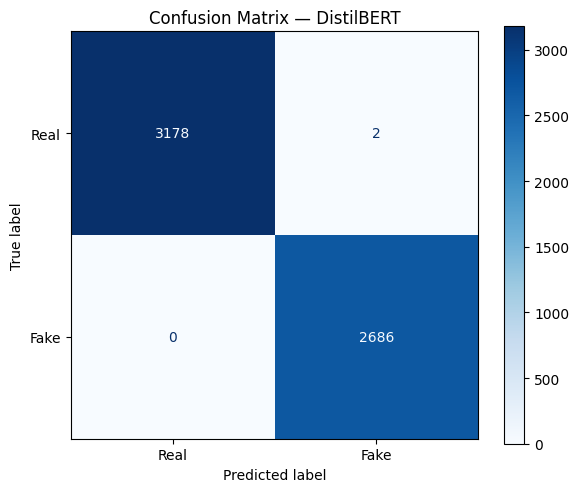

In [13]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — DistilBERT")
plt.tight_layout()
plt.show()

## 7. Training & Validation Loss Curves

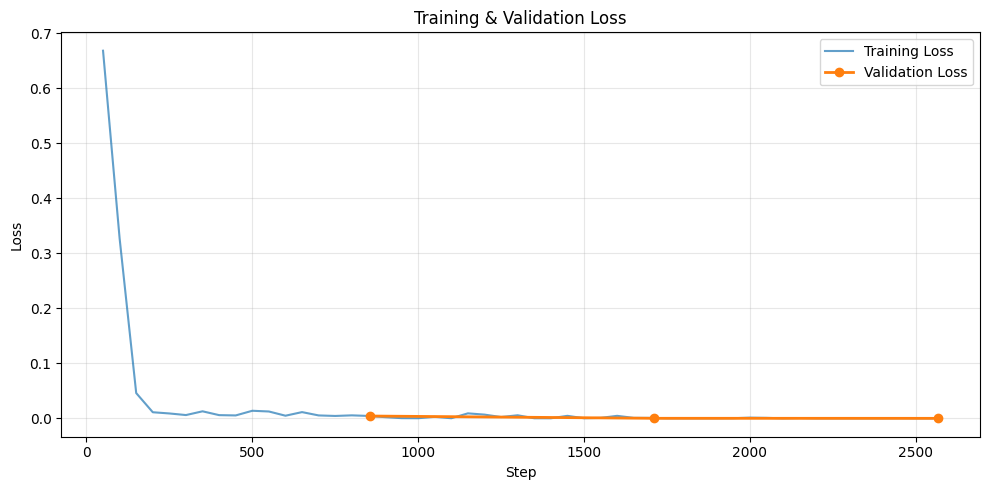

In [14]:
log = trainer.state.log_history

train_steps = [e["step"] for e in log if "loss" in e]
train_loss  = [e["loss"] for e in log if "loss" in e]
eval_steps  = [e["step"] for e in log if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Training Loss", alpha=0.7)
ax.plot(eval_steps,  eval_loss,  label="Validation Loss", marker="o", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save Model & Tokenizer

In [15]:
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Saved to: {SAVE_DIR}/")
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    if os.path.isfile(fpath):
        print(f"  {f:<45} {os.path.getsize(fpath)/1024:>10.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: models/fake_news_model/
  config.json                                          0.7 KB
  model.safetensors                               261555.2 KB
  tokenizer.json                                     695.0 KB
  tokenizer_config.json                                0.3 KB
  training_args.bin                                    5.1 KB


## 9. Inference — `predict_text()`

A self-contained function that:
1. Loads the saved model & tokenizer (once)
2. Tokenizes any input string
3. Returns the predicted label and confidence score

In [16]:
# ── Load saved model for inference ──
inf_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
inf_model     = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
inf_model.to(DEVICE)
inf_model.eval()
print(f"Inference model loaded from {SAVE_DIR}")


def predict_text(text: str) -> dict:
    """
    Predict whether a news article is Fake or Real.

    Args:
        text: The news article / headline to classify.

    Returns:
        dict with keys:
            - label (str):      "Fake" or "Real"
            - confidence (float): probability of the predicted class
    """
    inputs = inf_tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        logits = inf_model(**inputs).logits

    probs      = F.softmax(logits, dim=-1).squeeze()
    pred_id    = torch.argmax(probs).item()
    confidence = probs[pred_id].item()
    label      = "Fake" if pred_id == 1 else "Real"

    return {"label": label, "confidence": confidence}

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Inference model loaded from models/fake_news_model


In [17]:
demo_texts = [
    "BREAKING: Scientists discover high fat diet actually cures all diseases overnight",
    "WASHINGTON (Reuters) - The Senate voted on Thursday to approve the annual defense policy bill.",
    "Obama secretly planning to overthrow the government with help from aliens",
    "The Federal Reserve raised interest rates by 0.25% on Wednesday, citing steady economic growth.",
]

print(f"{'Prediction':<8}  {'Confidence':>10}  Text")
print("-" * 90)
for t in demo_texts:
    r = predict_text(t)
    print(f"[{r['label']:<4}]     {r['confidence']:>8.2%}    {t[:70]}...")

Prediction  Confidence  Text
------------------------------------------------------------------------------------------
[Fake]       99.94%    BREAKING: Scientists discover high fat diet actually cures all disease...
[Real]       99.99%    WASHINGTON (Reuters) - The Senate voted on Thursday to approve the ann...
[Fake]       99.82%    Obama secretly planning to overthrow the government with help from ali...
[Real]       97.29%    The Federal Reserve raised interest rates by 0.25% on Wednesday, citin...


## Summary

| Item | Detail |
|------|--------|
| Dataset | `data/fake_news_full_clean.csv` (ISOT, ~39k rows) |
| Input | `content` column (title + text) |
| Target | `label` — Real=0, Fake=1 |
| Base model | `distilbert-base-uncased` (66M params) |
| Max length | 256 tokens |
| Split | 70 / 15 / 15 (stratified) |
| Training | 3 epochs, batch=32, lr=2e-5, fp16 |
| Best model | Selected by validation F1 |
| Saved to | `models/fake_news_model/` |
| Inference | `predict_text(text)` → label + confidence |